In [1]:
from langgraph.graph import StateGraph, START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [3]:
load_dotenv()

llm_parent = ChatOpenAI(model="gpt-4o")
llm_subgraph = ChatOpenAI(model="gpt-4o-mini")


In [5]:
class SharedState(TypedDict):
    topic: str
    blog_text: str
    translated_text: str

In [6]:
def translate_blog(state: SharedState):
    prompt = f"""You are helpful assistant to convert provided statement to Hindi text. 
    Translation needs to be neat and clean. 
    Do not add any extra line. 
    Statement: {state['blog_text']}"""
    
    response = llm_subgraph.invoke(prompt).content
    
    return {"translated_text" : response}

In [7]:
sub_graph = StateGraph(SharedState)

sub_graph.add_node("translate_blog",translate_blog)

sub_graph.add_edge(START,"translate_blog")
sub_graph.add_edge("translate_blog",END)

subgraph = sub_graph.compile()

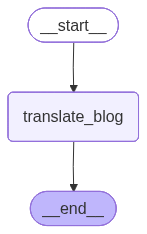

In [8]:
subgraph

In [9]:
def generate_blog(state: SharedState):
    prompt = f"""Generate a blog on user provided topic. Blog must have 100 words long only.
                Topic: {state.get("topic")}
                """
                
    blog = llm_parent.invoke(prompt).content
    
    return {"blog_text" : blog}

In [12]:
graph = StateGraph(SharedState)

graph.add_node("generate_blog",generate_blog)
graph.add_node("translate_blog",subgraph)

graph.add_edge(START,"generate_blog")
graph.add_edge("generate_blog","translate_blog")
graph.add_edge("translate_blog",END)
workflow = graph.compile()

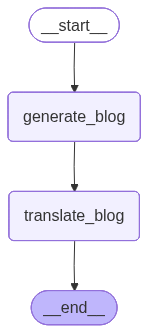

In [13]:
workflow

In [15]:
initial_state = {"topic": "Write a blog on tiger."}
result = workflow.invoke(initial_state)


In [16]:
print(result)

{'topic': 'Write a blog on tiger.', 'blog_text': 'Tigers, the majestic big cats known for their striking orange coats with black stripes, are emblematic of wild beauty and power. As apex predators, they play a crucial role in maintaining the balance of their ecosystem. Each subspecies, from the Siberian to the Bengal, showcases unique adaptations to their habitats. Unfortunately, these magnificent creatures face numerous threats, including habitat loss and poaching, leading them to the brink of extinction. Conservation efforts, such as protected reserves and anti-poaching initiatives, are vital to their survival. By supporting these efforts, we can ensure that future generations witness the awe-inspiring presence of tigers in the wild.', 'translated_text': 'बाघ, जो अपनी striking संतरी रंग की कोट के साथ काले धारियों के लिए जाने जाते हैं, जंगली सुंदरता और शक्ति के प्रतीक हैं। शीर्ष शिकारी के रूप में, वे अपने पारिस्थितिकी तंत्र के संतुलन को बनाए रखने में महत्वपूर्ण भूमिका निभाते हैं। प्रत